# **Phần 3: Giải hệ phương trình và phân tích hiệu năng**

**Thông tin nhóm:**
* **Môn học:** Toán Ứng Dụng và Thống Kê
* **Trường:** ĐH Khoa học Tự nhiên - ĐHQG TP.HCM
* **Nhóm:** 8
* **Lớp:** CQ2024/2
* **Thành viên:**
  1.   Nguyễn Đình Tuấn - 24120237
  2.   Nguyễn Anh Thái - 24120224
  3.   Nguyễn Huỳnh Gia Bảo - 24120264
  4.   Vòng Sau Hậu - 24120307
  5.   Lương Nhật Tân - 24120134

---

## **Giới thiệu tổng quan:**
* Thực hiện cài đặt phương pháp lặp Gauss-Seidel.
* Đánh giá hiệu năng (Execution Time) của các phương pháp: Gauss, LU, QR và Gauss-Seidel.
* Phân tích độ ổn định (L2 Relative Error) trên 3 loại ma trận: Ngẫu nhiên, SPD và Hilbert.
* Chứng minh độ phức tạp thuật toán thông qua biểu đồ Log-Log.
...

In [ ]:
import json

PATH = "benchmark_results.json"
with open(PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

scenarios = list(data["results"].keys())

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from ipywidgets import Dropdown, interact, fixed

def scenario_time_error_tables(data, scenario):
    sizes = np.array(data["sizes"], dtype=int)
    results = data["results"][scenario]
    solvers = list(results.keys())

    rows = []
    for solver in solvers:
        times = results[solver]["times"]
        errs  = results[solver]["errors"]
        for n, t, e in zip(sizes, times, errs):
            rows.append({
                "n": int(n),
                "solver": solver,
                "time_s": None if t is None else float(t),
                "error": e
            })

    df = pd.DataFrame(rows).sort_values(["n", "solver"]).reset_index(drop=True)

    time_tbl = df.pivot_table(index="n", columns="solver", values="time_s", aggfunc="first")
    err_tbl  = df.pivot_table(index="n", columns="solver", values="error",  aggfunc="first")

    time_tbl = time_tbl.style.format("{:.6g}", na_rep="—")
    return time_tbl, err_tbl

scenario_dd_tbl = Dropdown(options=scenarios, value=scenarios[0], description="Input Matrix:")

@interact(scenario=scenario_dd_tbl)
def _show_tables(scenario):
    time_tbl, err_tbl = scenario_time_error_tables(data, scenario)
    print("==== Thời gian thực thi (giây) ====")
    display(time_tbl)
    print("\n==== Sai số tương đối L2 ====")
    display(err_tbl)

interactive(children=(Dropdown(description='Input Matrix:', options=('Ngẫu nhiên bình thường', 'SPD (Xác định …

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from ipywidgets import Dropdown, interact

def _safe_points(sizes, values):
    xs, ys = [], []
    for n, v in zip(sizes, values):
        if v is None: continue
        try:
            val = float(v)
            if np.isfinite(val) and val > 0:
                xs.append(float(n))
                ys.append(val)
        except: continue
    return np.array(xs), np.array(ys)

def plot_combined_analysis(data, scenario, fig_w=10, fig_h=10, dpi=120):
    sizes = np.array(data["sizes"], dtype=float)
    results = data["results"][scenario]
    solvers = list(results.keys())

    # Định nghĩa màu sắc và marker đồng nhất
    styles = {
        'Gauss': {'c': '#1f77b4', 'm': 'o'},
        'LU': {'c': '#2ca02c', 'm': 's'},
        'QR': {'c': '#d62728', 'm': '^'},
        'Gauss-Seidel': {'c': '#9467bd', 'm': 'D'}
    }

    plt.close("all")
    # Tạo 2 biểu đồ con (subplot): trên là thời gian, dưới là sai số
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(fig_w, fig_h), dpi=dpi)

    # --- BIỂU ĐỒ 1: THỜI GIAN ---
    for solver in solvers:
        x, t = _safe_points(sizes, results[solver]["times"])
        if x.size:
            ax1.plot(x, t, marker=styles.get(solver, {}).get('m', 'o'),
                     color=styles.get(solver, {}).get('c', 'black'),
                     linewidth=2, markersize=7, label=solver, alpha=0.9)

    # Đường tham chiếu O(N^3) cho thời gian
    gauss_times = [t for t in results.get('Gauss', {}).get('times', []) if t is not None]
    if gauss_times:
        c = float(gauss_times[0]) / (sizes[0]**3)
        ax1.plot(sizes, [c * (n**3) for n in sizes], color='black', linestyle='--', label=r'Lý thuyết $\mathcal{O}(n^3)$')

    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_xticks(sizes)
    ax1.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    ax1.set_xlabel("Kích thước ma trận N", fontsize=11, fontweight='bold')
    ax1.set_ylabel("Thời gian thực thi [s]", fontsize=11, fontweight='bold')
    ax1.set_title(f"Biểu đồ log-log thời gian thực thi theo kích thước ma trận: {scenario}", fontsize=14, fontweight='bold')
    ax1.grid(True, which="both", linestyle=":", alpha=0.5)
    ax1.legend(fontsize=9)

    # --- BIỂU ĐỒ 2: SAI SỐ (STABILITY) ---
    for solver in solvers:
        x, err = _safe_points(sizes, results[solver]["errors"])
        if x.size:
            ax2.plot(x, err, marker=styles.get(solver, {}).get('m', 'o'),
                     color=styles.get(solver, {}).get('c', 'black'),
                     linewidth=2, markersize=7, label=solver, alpha=0.9)
    ax2.set_title(f"Biểu đồ log-log sai số L2 theo kích thước ma trận: {scenario}", fontsize=14, fontweight='bold')
    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_xticks(sizes)
    ax2.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

    ax2.set_xlabel("Kích thước ma trận N", fontsize=11, fontweight='bold')
    ax2.set_ylabel("Sai số tương đối L2", fontsize=11, fontweight='bold')
    ax2.grid(True, which="both", linestyle=":", alpha=0.5)
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.show()


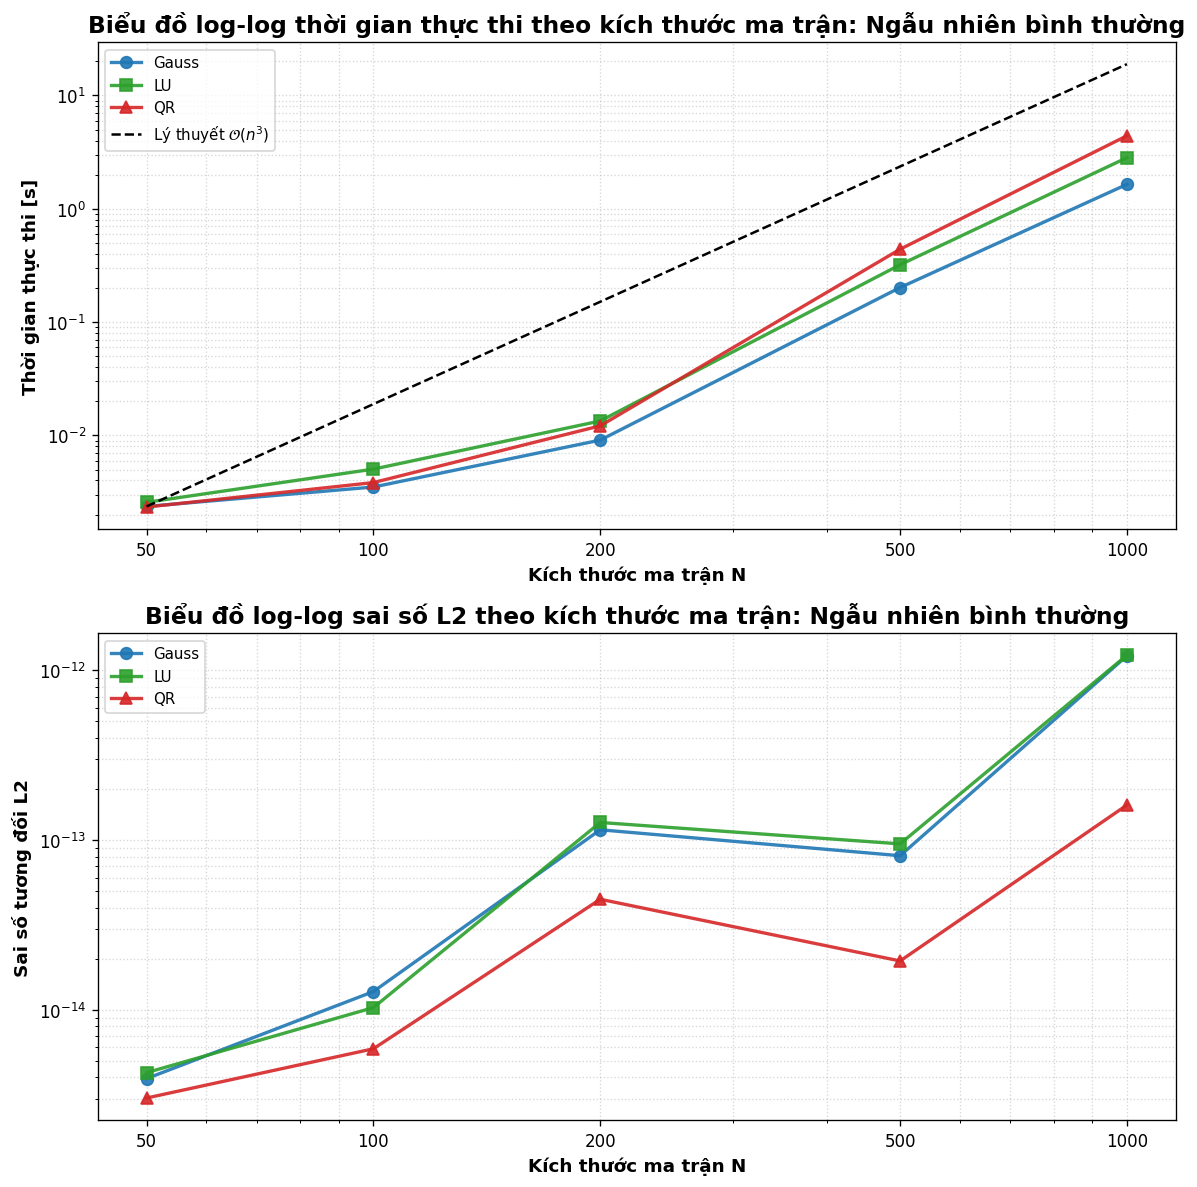

In [ ]:
plot_combined_analysis(data, "Ngẫu nhiên bình thường")

## 1. Phân tích hiệu năng và độ ổn đinh: ma trận ngẫu nhiên (bình thường)
> ### 1.1. Phân tích Hiệu năng (Thời gian thực thi)

Dựa trên biểu đồ Log-Log về thời gian thực thi:

- **Xu hướng đường biểu diễn:**  
  Các đường thời gian của Gauss, LU và QR đều là những đường thẳng tăng đều, mượt và ổn định. Điều này cho thấy thuật toán hoạt động ổn định, không có hiện tượng gián đoạn hay tăng đột biến khi kích thước tăng từ $n=50$ lên $n=1000$.

- **Đặc điểm từng thuật toán:**
  - **Gauss:** Nhanh nhất do số lượng phép tính tối thiểu.
  - **LU & QR (Householder):** Chậm hơn Gauss nhưng vẫn giữ độ dốc ổn định, phản ánh chi phí phân rã ma trận.
  - **Gauss > LU > QR**

> ### 1.2. Phân tích độ ổn định sai số

Sai số được đánh giá qua:

$$
\frac{\|A\hat{x} - b\|_2}{\|b\|_2}
$$

- **Xu hướng đường biểu diễn:**

  - **Giai đoạn đầu ($N < 200$):**  
    Cả ba có sai số rất nhỏ (~$3 \times 10^{-15}$ đến $5 \times 10^{-15}$). Khi $N$ tăng đến $100$, QR tăng nhẹ (dưới $10^{-14}$), còn Gauss và LU tăng nhanh hơn và vượt mức này.
  - **Giai đoạn sau ($200 \le N \le 1000$):**  
    Sai số tăng mạnh khi $N = 200$, sau đó giảm nhẹ tại  $N=500$ rồi tiếp tục tăng. Ở $N = 1000$, Gauss và LU tăng vọt, vượt $10^{-12}$.

- **So sánh các phương pháp:**

  - **QR (Householder):**  
    Luôn có sai số thấp nhất.  
    Tại $n=1000$:

$$
\approx 1.61 \times 10^{-13}
$$

  - **Gauss & LU:**  
    Sai số cao hơn, khoảng:

$$
\approx 1.2 \times 10^{-12}
$$

→ Tất cả phương pháp đều kém chính xác hơn khi ma trận lớn. Tuy nhiên, QR là lựa chọn tốt nhất nếu cần giảm sai số trong tính toán ma trận lớn.


> ### 1.3. Khó khăn khi kiểm thử phương pháp lặp Gauss-Seidel

- **Kết quả:**  
  Với ma trận ngẫu nhiên, thuật toán trả về lỗi không thỏa mãn điều kiện hội tụ.

- **Lý thuyết:**  
  Phương pháp yêu cầu điều kiện chéo trội:

$$
|a_{ii}| > \sum_{j \ne i} |a_{ij}|, \quad \forall i = 1, \dots, n
$$

- **Hệ quả:**  
  Ma trận ngẫu nhiên không đảm bảo cấu trúc này, nên không thể so sánh trực tiếp với các phương pháp trực tiếp.


> ### 1.4. Kết luận

- **Về thời gian thực thi:**  
  Các thuật toán hoạt động ổn định, đường thời gian mượt và khá sát đúng với lý thuyết.

- **Về độ ổn định (sai số $L2$):**
  - QR: ổn định nhất với sai số nhỏ nhất  
  - Gauss, LU: ổn định nhưng kém hơn QR

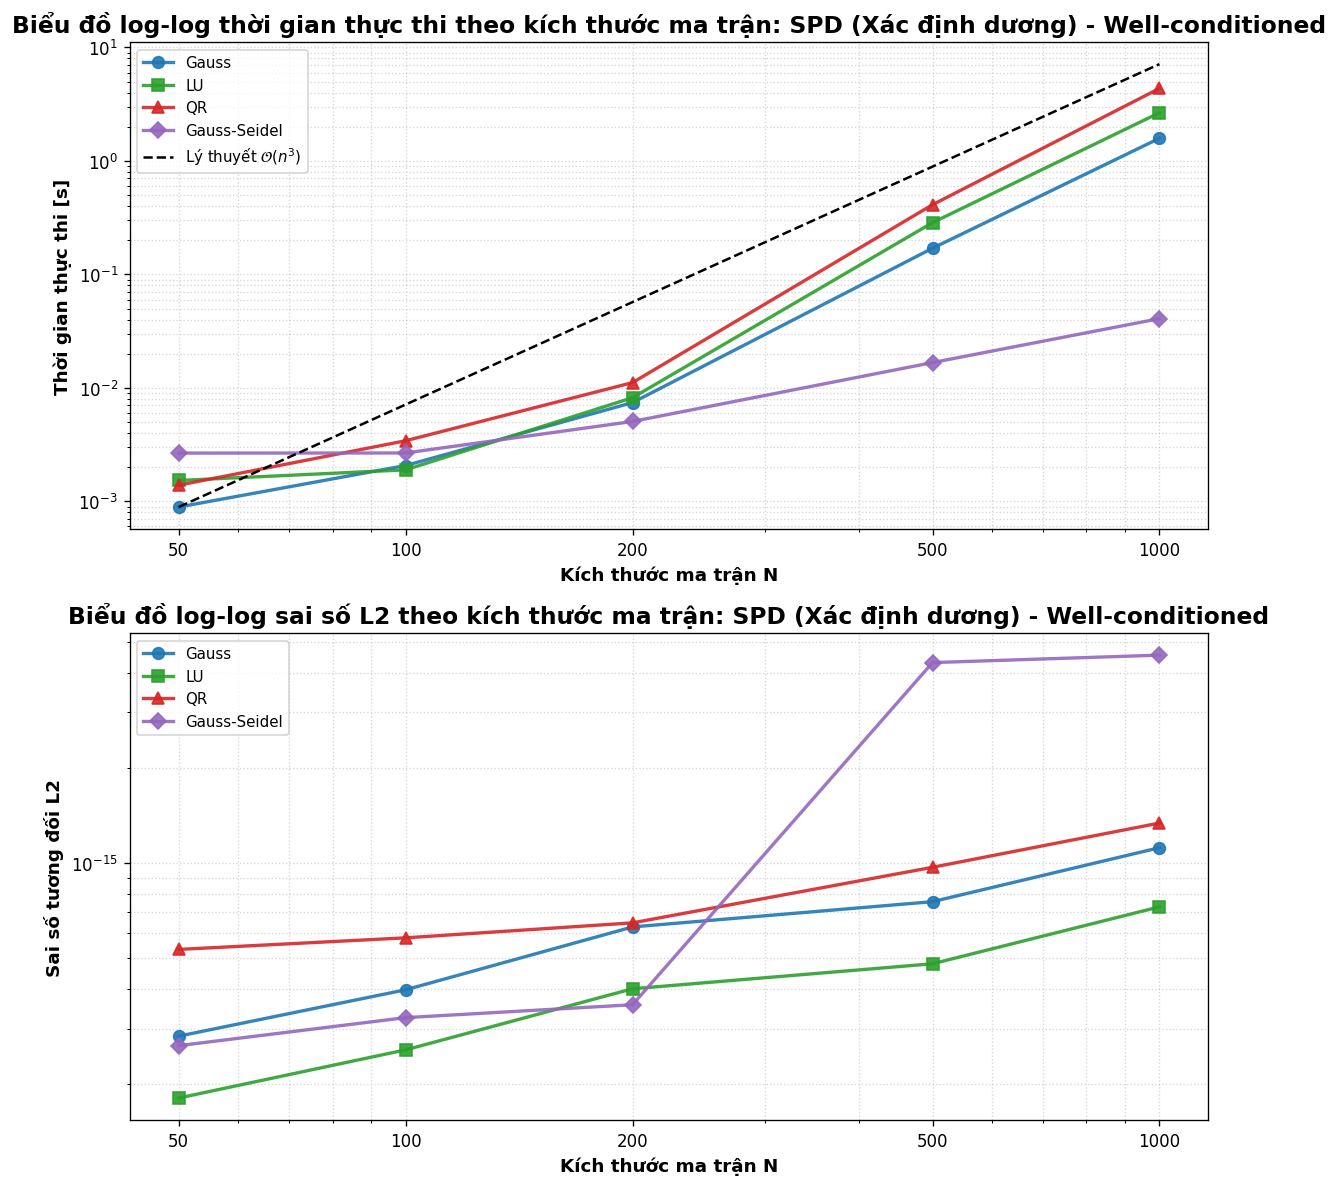

In [ ]:
plot_combined_analysis(data, "SPD (Xác định dương) - Well-conditioned")

## 2. Phân tích hiệu năng và độ ổn định: Ma trận SPD (Well-conditioned)

### 2.1. Phân tích Hiệu năng (Thời gian thực thi)

Dựa trên biểu đồ thời gian, ta thấy sự phân hóa rõ rệt giữa các nhóm thuật toán:

- **Nhóm phương pháp trực tiếp (Gauss, LU, QR):**  

  - **Đặc điểm thực nghiệm ($n=1000$):**  
    Gauss ($1.58s$) nhanh nhất, tiếp theo là LU ($2.65s$) và cuối cùng là QR ($4.35s$).
    Sự chênh lệch đến từ số lượng phép tính dấu phẩy động khác nhau giữa khử dòng và các phép biến đổi trực giao.

- **Phương pháp lặp Gauss-Seidel:**

  - **Xu hướng:**  
    Có độ dốc thấp hơn cho thấy thời gian thực thi nhanh hơn, tiệm cận độ phức tạp:

$$
O(k \cdot n^2)
$$

  với $k$ là số bước lặp.

  - **Thực nghiệm:**  
    Tại $n=1000$, thời gian thực thi của phương pháp Gauss-Seidel chỉ khoảng $0.04s$, cho thấy hiệu năng vượt trội so với phương pháp trực tiếp.

### 2.2. Phân tích Độ ổn định sai số

Độ ổn định được đánh giá qua sai số:

$$
\frac{\|A\hat{x} - b\|_2}{\|b\|_2}
$$

- **Số điều kiện (Condition Number):**  
  Với ma trận SPD (well-conditioned), số điều kiện nhỏ:

$$
\kappa(A) = \|A\| \cdot \|A^{-1}\|
$$

  → Sai số được kiểm soát tốt theo:

$$
\frac{\|\hat{x} - x\|}{\|x\|} \le \kappa(A) \cdot \frac{\|\delta b\|}{\|b\|}
$$

- **Sự ổn định của các phương pháp:**

  - **LU** có sai số thấp nhất (~$10^{-15}$ đến $10^{-14}$) và ổn định nhất trong toàn bộ quá trình.
  - **Gauss** và **QR** tăng đều, với QR ban đầu cao hơn nhưng dần tiệm cận Gauss.
  - **Gauss-Seidel** mất ổn định khi $N$ lớn và sai số tăng mạnh. Sai số có thể bị "gấp khúc" tại $n = 200$, điều này giải thích bởi việc tích lũy sai số làm tròn qua hàng ngàn phép tính thành phần trong mỗi bước lặp:

$$
x_i^{(k+1)} = \frac{1}{a_{ii}} \left(
b_i
- \sum_{j=1}^{i-1} a_{ij} x_j^{(k+1)}
- \sum_{j=i+1}^{n} a_{ij} x_j^{(k)}
\right)
$$


### 2.3. Lợi thế của phương pháp lặp Gauss-Seidel trên ma trận SPD

Ma trận SPD mang lại nhiều lợi thế lý thuyết:

- **Hội tụ chắc chắn:**  
  Đảm bảo hội tụ ngay cả khi không chéo trội ngặt.

- **Tốc độ hội tụ nhanh:**  
  Với số điều kiện nhỏ, số bước lặp $k$ cần thiết cũng nhỏ → giảm đáng kể thời gian so với $O(n^3)$.


### 2.4. Kết luận

- **Về thời gian thực thi:**  
  Gauss-Seidel là lựa chọn tối ưu về tốc độ cho ma trận SPD lớn.

- **Về sai số $L2$:**  
  Nhóm phương pháp trực tiếp (đặc biệt LU/Gauss/QR) cho độ chính xác cao và ổn định.

- **Khả năng mở rộng:**  
  Kết hợp giữa tốc độ của Gauss-Seidel và độ chính xác của LU là phương án tối ưu cho hệ thực tế.

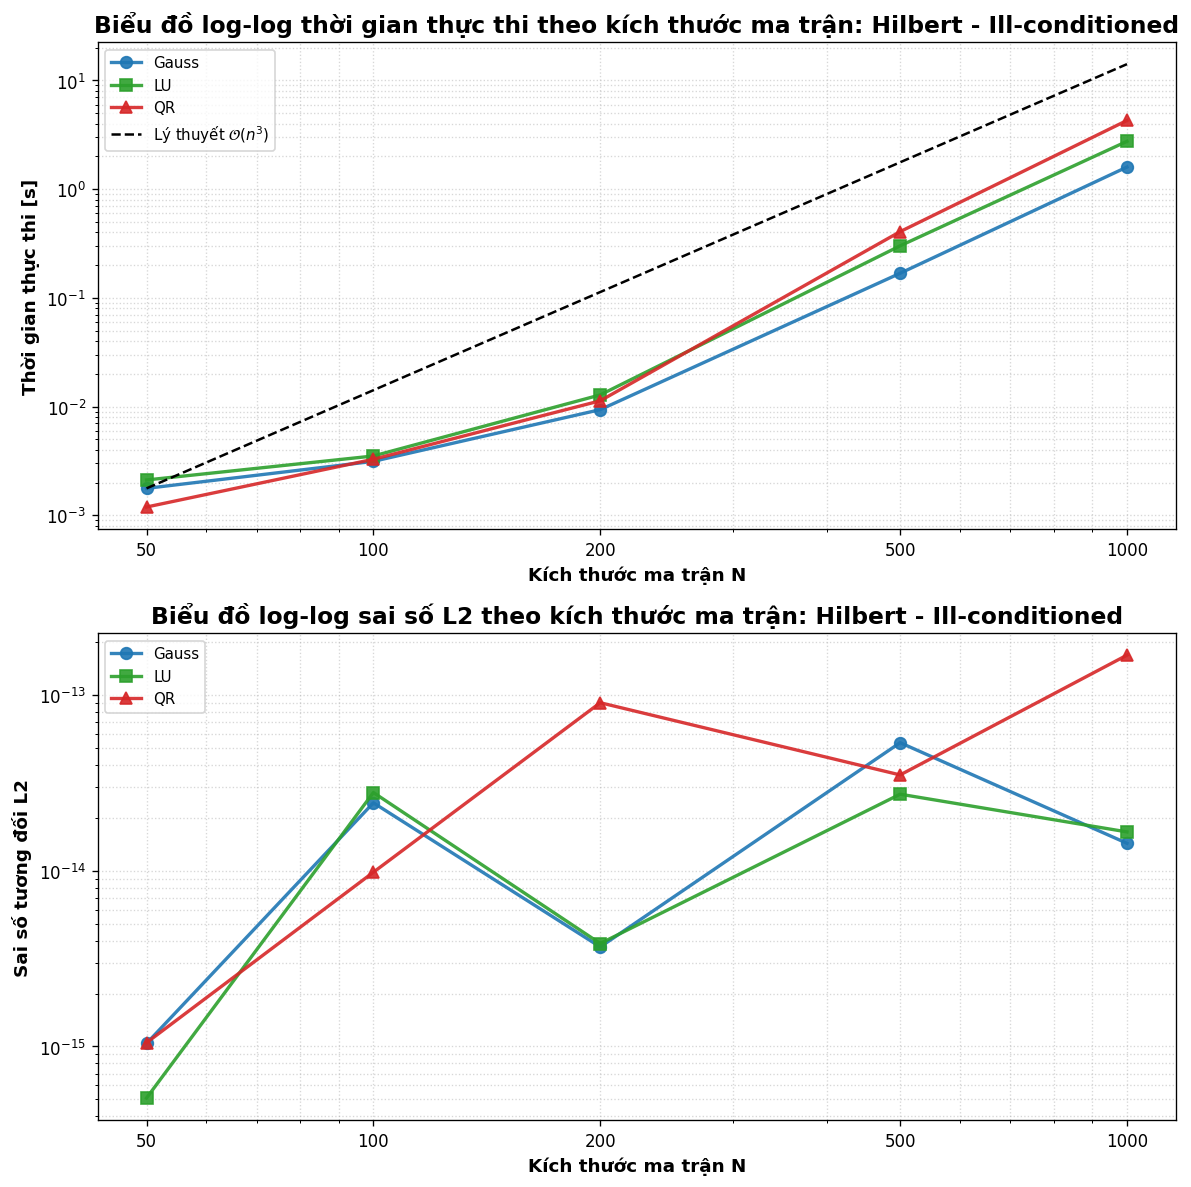

In [ ]:
plot_combined_analysis(data, "Hilbert - Ill-conditioned")

## 3. Phân tích hiệu năng và độ ổn định: Ma trận Hilbert (Ill-conditioned)

### 3.1. Phân tích Hiệu năng (Thời gian thực thi)

Dựa trên biểu đồ thời gian và dữ liệu thực tế:

- **Xu hướng đường biểu diễn:**  
  Trái ngược với sự hỗn loạn của sai số, các đường thời gian của Gauss, LU và QR đều là những đường thẳng mượt trên thang Log-Log.

- **Tính ổn định về hiệu năng:**  
  Điều này cho thấy chi phí tính toán chỉ phụ thuộc vào kích thước ma trận $n$, không phụ thuộc vào giá trị phần tử.

$$
O(n^3)
$$

- **Đặc điểm từng thuật toán (tại $n=1000$):**
  - **Gauss ($1.59s$):** Nhanh nhất.
  - **LU ($2.75s$):** Chậm hơn Gauss khoảng $1.7$ lần.
  - **QR (Householder) ($4.28s$):** Chậm nhất do chi phí biến đổi trực giao.

### 3.2. Phân tích độ ổn định sai số

Đây là nơi bản chất ill-conditioned của ma trận Hilbert thể hiện rõ nhất:

- **Xu hướng "gấp khúc" mạnh:**  
  Đường sai số dao động liên tục, trồi sụt thất thường, không còn mượt hay tăng tuyến tính.

- **Giải thích qua số điều kiện:**

$$
\kappa_p(A) = \|A\|_p \cdot \|A^{-1}\|_p
$$

Với Hilbert, $\kappa(A)$ tăng rất nhanh theo $n$ → hệ cực kỳ nhạy với sai số.

- **Hệ quả lên sai số nghiệm:**

$$
\frac{\|\hat{x} - x\|}{\|x\|} \le \kappa(A)\cdot \frac{\|\delta b\|}{\|b\|}
$$

→ Sai số làm tròn nhỏ bị khuếch đại mạnh → kết quả dao động khó kiểm soát.

- **Biểu hiện trên đồ thị:**
  - Tại $n=200$, sai số QR tăng vọt gần $10^{-13}$
  - Nhưng tại $n=500$ lại thấp hơn  
  → Đường bị **gấp khúc mạnh**, không ổn định

- **Kết luận phần này:**
  - Khi $n$ lớn, các phương pháp trực tiếp **không còn giữ được độ ổn định số học**

### 3.3. Sự bất khả thi của phương pháp lặp Gauss-Seidel

- **Kết quả thực nghiệm:**  
  Gauss-Seidel trả về giá trị null → không hội tụ.

- **Nguyên nhân lý thuyết:**
  - Yêu cầu điều kiện hội tụ:
  
$$
|a_{ii}| > \sum_{j \ne i} |a_{ij}|
$$

  - Ma trận Hilbert **không thỏa mãn chéo trội**

→ Thuật toán **phân kỳ ngay từ đầu**

- **Hệ quả:**
  - Không thể áp dụng phương pháp lặp
  - Không thể so sánh với các phương pháp trực tiếp

### 3.4. Kết luận

- **Về hiệu năng:**
  - Các thuật toán vẫn tuân theo:

$$
O(n^3)
$$

  - Đường thời gian tăng đều, mượt và ổn định

- **Về độ ổn định:**
  - Đường sai số:
    - Dao động mạnh  
    - Gấp khúc liên tục  
  → Thể hiện tính **không ổn định nghiêm trọng**